In [1]:

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Print-friendly plotting helpers for black-and-white Xerox copies.
PRINT_HATCHES = ["", "///", "\\\\", "xx", "..", "++", "--", "oo", "**", "OO"]
PRINT_MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
PRINT_GRAYS = ["#111111", "#444444", "#777777", "#AAAAAA", "#DDDDDD"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#111111",
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "grid.color": "#D0D0D0",
})

def print_palette(n):
    if n <= 0:
        return []
    return [PRINT_GRAYS[i % len(PRINT_GRAYS)] for i in range(n)]

def apply_bar_hatches(ax, hatches=PRINT_HATCHES):
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor("white")
        patch.set_edgecolor("#111111")
        patch.set_linewidth(1.0)
        patch.set_hatch(hatches[i % len(hatches)])
    return ax

def boxplot_print(data, x, y, ax=None, showfliers=False):
    ax = ax or plt.gca()
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        ax=ax,
        color="white",
        showfliers=showfliers,
        boxprops={"facecolor": "white", "edgecolor": "#111111", "linewidth": 1.0},
        medianprops={"color": "#111111", "linewidth": 1.3},
        whiskerprops={"color": "#111111", "linewidth": 1.0},
        capprops={"color": "#111111", "linewidth": 1.0},
    )
    for i, patch in enumerate(ax.patches):
        patch.set_hatch(PRINT_HATCHES[i % len(PRINT_HATCHES)])
        patch.set_edgecolor("#111111")
    return ax

def scatter_with_markers(data, x, y, hue, title, xlabel=None, ylabel=None, max_legend_items=12):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    labels = data[hue].astype("string").fillna("<NA>")
    order = labels.value_counts().index.tolist()
    if len(order) > max_legend_items:
        keep = set(order[:max_legend_items - 1])
        plot_data = data.copy()
        plot_data[hue] = labels.where(labels.isin(keep), "Other")
        labels = plot_data[hue].astype("string")
        order = labels.value_counts().index.tolist()
    else:
        plot_data = data.copy()
        plot_data[hue] = labels

    for i, label in enumerate(order):
        subset = plot_data[plot_data[hue].astype("string") == str(label)]
        ax.scatter(
            subset[x],
            subset[y],
            marker=PRINT_MARKERS[i % len(PRINT_MARKERS)],
            facecolors="none",
            edgecolors="#111111",
            linewidths=0.75,
            alpha=0.7,
            s=24,
            label=str(label),
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    return ax


RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50_000

def find_data_file(filename):
    candidates = [
        Path(filename),
        Path("eda") / filename,
        Path("..") / "eda" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")

def display_basic_profile(df, target_col=None):
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    profile = pd.DataFrame({
        "metric": ["rows", "columns", "memory_mb", "duplicate_rows", "total_missing_cells"],
        "value": [len(df), df.shape[1], round(memory_mb, 2), int(df.duplicated().sum()), int(df.isna().sum().sum())],
    })
    display(profile)
    if target_col and target_col in df.columns:
        target_summary = (
            df[target_col]
            .value_counts(dropna=False)
            .rename_axis(target_col)
            .reset_index(name="count")
        )
        target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(2)
        display(target_summary)

def get_numeric_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]

def get_categorical_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=["object", "string", "category", "bool"]).columns if c not in exclude]

def sampled(df, n=PLOT_SAMPLE_SIZE):
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_STATE)

def plot_target_distribution(df, target_col, title):
    order = df[target_col].value_counts(dropna=False).index
    plt.figure(figsize=(8, 4.5))
    ax = sns.countplot(data=df, x=target_col, order=order, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    ax.set_title(title)
    ax.set_xlabel(target_col)
    ax.set_ylabel("Rows")
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_missing_values(df):
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0].head(20)
    if missing.empty:
        display(Markdown("No missing values after loading and standard cleanup."))
        return
    plt.figure(figsize=(10, max(3, len(missing) * 0.3)))
    ax = sns.barplot(x=missing.values, y=missing.index, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title("Top columns by missing value count")
    plt.xlabel("Missing cells")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_numeric_distributions(df, columns, title):
    if not columns:
        display(Markdown("No numeric columns available for distribution plots."))
        return
    sample = sampled(df)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = pd.to_numeric(sample[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            ax.set_visible(False)
            continue
        label = col
        if values.min() >= 0 and values.quantile(0.99) > max(values.median() * 10, 10):
            values = np.log1p(values)
            label = f"log1p({col})"
        sns.histplot(values, bins=40, kde=True, ax=ax, color="#D9D9D9", edgecolor="#111111", line_kws={"color": "#111111"})
        ax.set_title(col)
        ax.set_xlabel(label)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_categorical_top_counts(df, columns, title):
    if not columns:
        display(Markdown("No categorical columns available for count plots."))
        return
    n_cols = min(2, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        counts = df[col].astype("string").fillna("<NA>").value_counts().head(12)
        sns.barplot(x=counts.values, y=counts.index, ax=ax, color="white", edgecolor="#111111")
        apply_bar_hatches(ax)
        ax.set_title(col)
        ax.set_xlabel("Rows")
        ax.set_ylabel("")
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def target_association(df, target_col, numeric_cols, exclude=None):
    exclude = set(exclude or []) | {target_col}
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    if target_col not in df.columns or not numeric_cols:
        return pd.Series(dtype="float64")
    y = pd.Series(pd.factorize(df[target_col].astype("string"))[0], index=df.index)
    values = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    corr = values.corrwith(y).abs().sort_values(ascending=False)
    return corr.dropna()

def plot_correlation_heatmap(df, numeric_cols, title, max_features=18):
    numeric_cols = list(numeric_cols)[:max_features]
    if len(numeric_cols) < 2:
        display(Markdown("Not enough numeric columns for a correlation heatmap."))
        return
    corr = df[numeric_cols].replace([np.inf, -np.inf], np.nan).corr()
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap="Greys", center=0, linewidths=0.3, square=False, linecolor="#CCCCCC")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_numeric_by_target(df, target_col, columns, title):
    if not columns:
        display(Markdown("No numeric columns selected for target comparison."))
        return
    sample = sampled(df, 30_000)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = sample[[target_col, col]].copy()
        values[col] = pd.to_numeric(values[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        values = values.dropna(subset=[col])
        if values.empty:
            ax.set_visible(False)
            continue
        if values[col].min() >= 0 and values[col].quantile(0.99) > max(values[col].median() * 10, 10):
            values[col] = np.log1p(values[col])
            ylabel = f"log1p({col})"
        else:
            ylabel = col
        boxplot_print(values, target_col, col, ax=ax, showfliers=False)
        ax.set_title(col)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## Load Data

In [2]:

import re

DATA_PATH = find_data_file("KDDTrain+.arff")

def parse_arff_attributes(path):
    attributes = []
    data_start_line = None
    attribute_pattern = re.compile(r"@attribute\s+'?([^'\s]+)'?\s+(.+)", re.IGNORECASE)
    with open(path, "r", encoding="utf-8", errors="replace") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped or stripped.startswith("%"):
                continue
            if stripped.lower().startswith("@attribute"):
                match = attribute_pattern.match(stripped)
                if match:
                    attributes.append(match.group(1).strip().strip("'"))
                else:
                    attributes.append(stripped.split()[1].strip().strip("'"))
            elif stripped.lower().startswith("@data"):
                data_start_line = line_number
                break
    if data_start_line is None:
        raise ValueError("No @data marker found in ARFF file")
    return attributes, data_start_line

columns, data_start_line = parse_arff_attributes(DATA_PATH)
df = pd.read_csv(DATA_PATH, comment="%", skiprows=data_start_line, header=None, names=columns)

# Normalize string columns. This file has quoted attribute declarations but unquoted data values.
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("string").str.strip().str.strip("'")

print(f"Loaded from: {DATA_PATH}")
print(f"Parsed attributes: {len(columns)}")


Loaded from: KDDTrain+.arff
Parsed attributes: 42


In [3]:
TARGET_COL = 'class'
EXCLUDE_COLS = ['class']
PREFERRED_NUMERIC = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count']
PREFERRED_CATEGORICAL = ['protocol_type', 'service', 'flag', 'class']

display_basic_profile(df, TARGET_COL)
display(df.head())

,metric,value
0,rows,"125,973.0000"
1,columns,42.0000
2,memory_mb,62.1300
3,duplicate_rows,9.0000
4,total_missing_cells,0.0000


,class,count,percent
0,normal,67343,53.4600
1,anomaly,58630,46.5400


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,150,25,0.1700,0.0300,0.1700,0.0000,0.0000,0.0000,0.0500,0.0000,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0000,0.0000,0.0000,0.0000,0.0800,0.1500,0.0000,255,1,0.0000,0.6000,0.8800,0.0000,0.0000,0.0000,0.0000,0.0000,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0000,1.0000,0.0000,0.0000,0.0500,0.0700,0.0000,255,26,0.1000,0.0500,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2000,0.2000,0.0000,0.0000,1.0000,0.0000,0.0000,30,255,1.0000,0.0000,0.0300,0.0400,0.0300,0.0100,0.0000,0.0100,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0900,255,255,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,normal


## Data Quality

In [4]:

# Data quality checks
missing = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(3)
missing = missing.sort_values("missing_count", ascending=False)

dtype_summary = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "unique": df.nunique(dropna=False),
    })
    .sort_values(["missing", "unique"], ascending=[False, False])
)

display(dtype_summary.head(30))
display(missing.head(20))
plot_missing_values(df)


,dtype,non_null,missing,unique
dst_bytes,int64,125973,0,9326
src_bytes,int64,125973,0,3341
duration,int64,125973,0,2981
count,int64,125973,0,512
srv_count,int64,125973,0,509
dst_host_count,int64,125973,0,256
dst_host_srv_count,int64,125973,0,256
same_srv_rate,float64,125973,0,101
dst_host_same_srv_rate,float64,125973,0,101
dst_host_diff_srv_rate,float64,125973,0,101


,missing_count,missing_percent
duration,0,0.0000
protocol_type,0,0.0000
service,0,0.0000
flag,0,0.0000
src_bytes,0,0.0000
dst_bytes,0,0.0000
land,0,0.0000
wrong_fragment,0,0.0000
urgent,0,0.0000
hot,0,0.0000


No missing values after loading and standard cleanup.

## Target Distribution

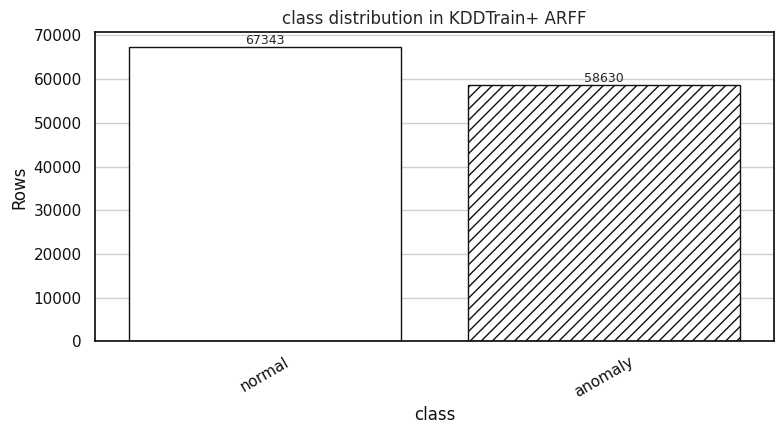

In [5]:
plot_target_distribution(df, TARGET_COL, f"{TARGET_COL} distribution in KDDTrain+ ARFF")

## Feature Summaries

In [6]:

# Numeric and categorical summaries
numeric_cols = get_numeric_columns(df, exclude=EXCLUDE_COLS)
categorical_cols = get_categorical_columns(df, exclude=EXCLUDE_COLS)

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T if numeric_cols else pd.DataFrame())

categorical_profile = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[c].nunique(dropna=False) for c in categorical_cols],
    "top_value": [df[c].astype("string").fillna("<NA>").mode().iloc[0] if not df[c].mode(dropna=False).empty else None for c in categorical_cols],
    "top_count": [df[c].astype("string").fillna("<NA>").value_counts().iloc[0] if len(df) else 0 for c in categorical_cols],
})
display(categorical_profile.sort_values("unique_values", ascending=False))


Numeric columns: 38
Categorical columns: 3


,count,mean,std,min,1%,5%,50%,95%,99%,max
duration,"125,973.0000",287.1447,"2,604.5153",0.0000,0.0000,0.0000,0.0000,4.0000,"9,590.5600","42,908.0000"
src_bytes,"125,973.0000","45,566.7430","5,870,331.1819",0.0000,0.0000,0.0000,44.0000,"1,480.0000","54,540.0000","1,379,963,888.0000"
dst_bytes,"125,973.0000","19,779.1144","4,021,269.1514",0.0000,0.0000,0.0000,0.0000,"8,314.0000","25,519.0000","1,309,937,401.0000"
land,"125,973.0000",0.0002,0.0141,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
wrong_fragment,"125,973.0000",0.0227,0.2535,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
urgent,"125,973.0000",0.0001,0.0144,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
hot,"125,973.0000",0.2044,2.1500,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,77.0000
num_failed_logins,"125,973.0000",0.0012,0.0452,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000
logged_in,"125,973.0000",0.3957,0.4890,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
num_compromised,"125,973.0000",0.2793,23.9420,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,"7,479.0000"


,column,unique_values,top_value,top_count
1,service,70,http,40338
2,flag,11,SF,74945
0,protocol_type,3,tcp,102689


## Univariate Patterns

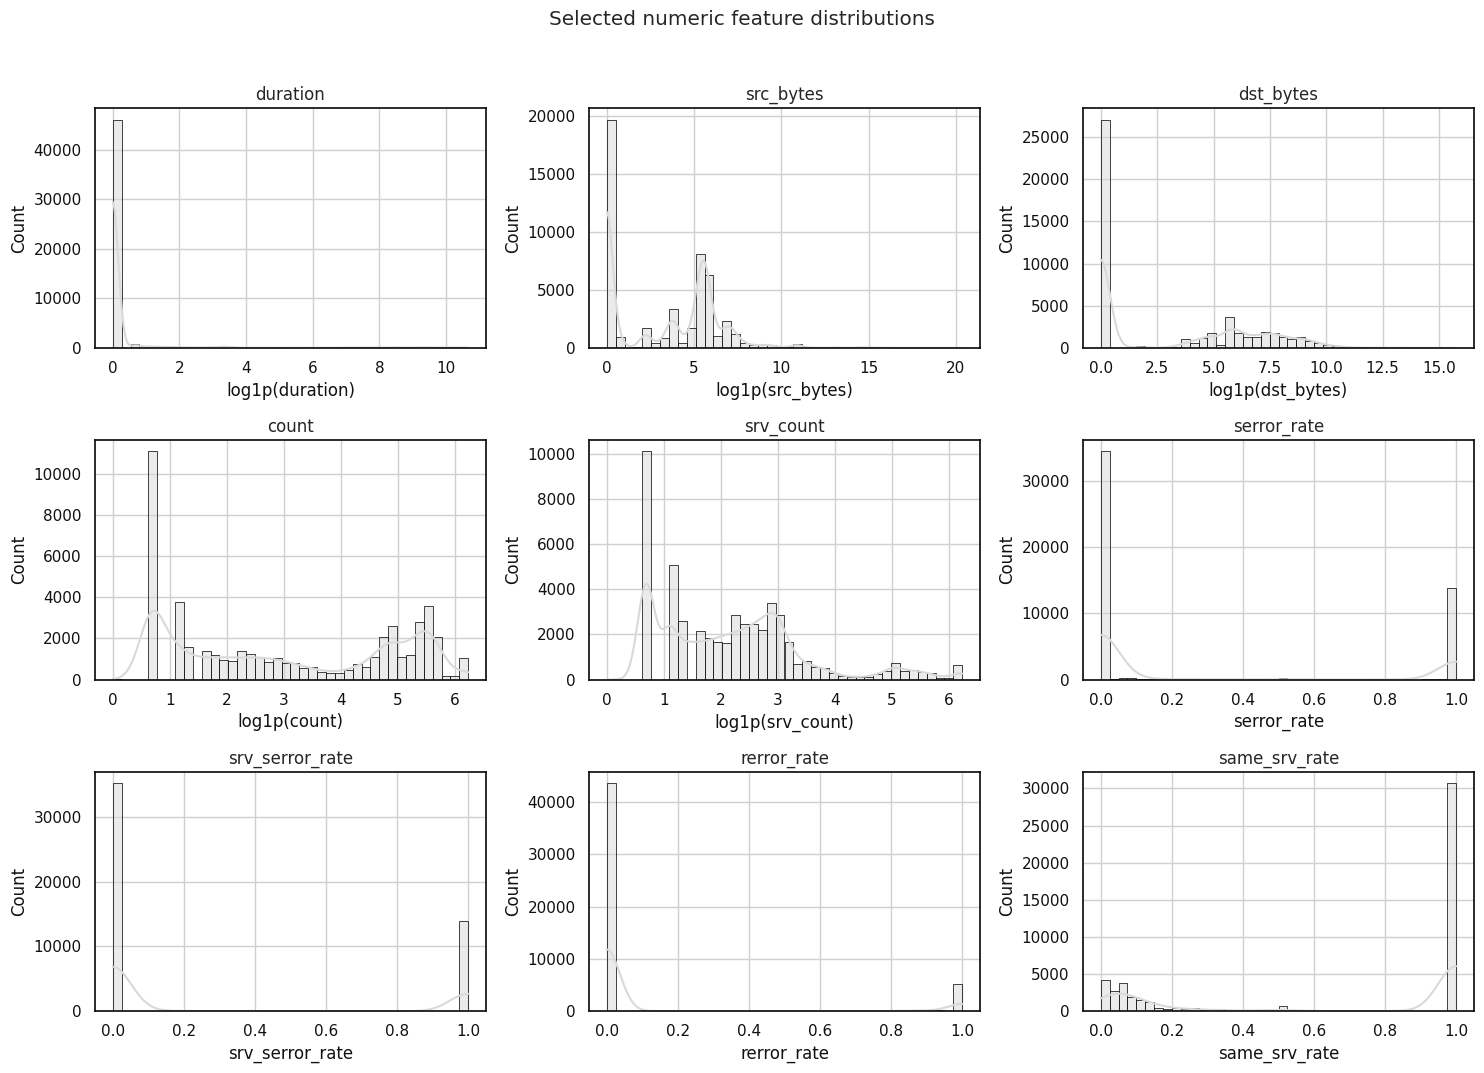

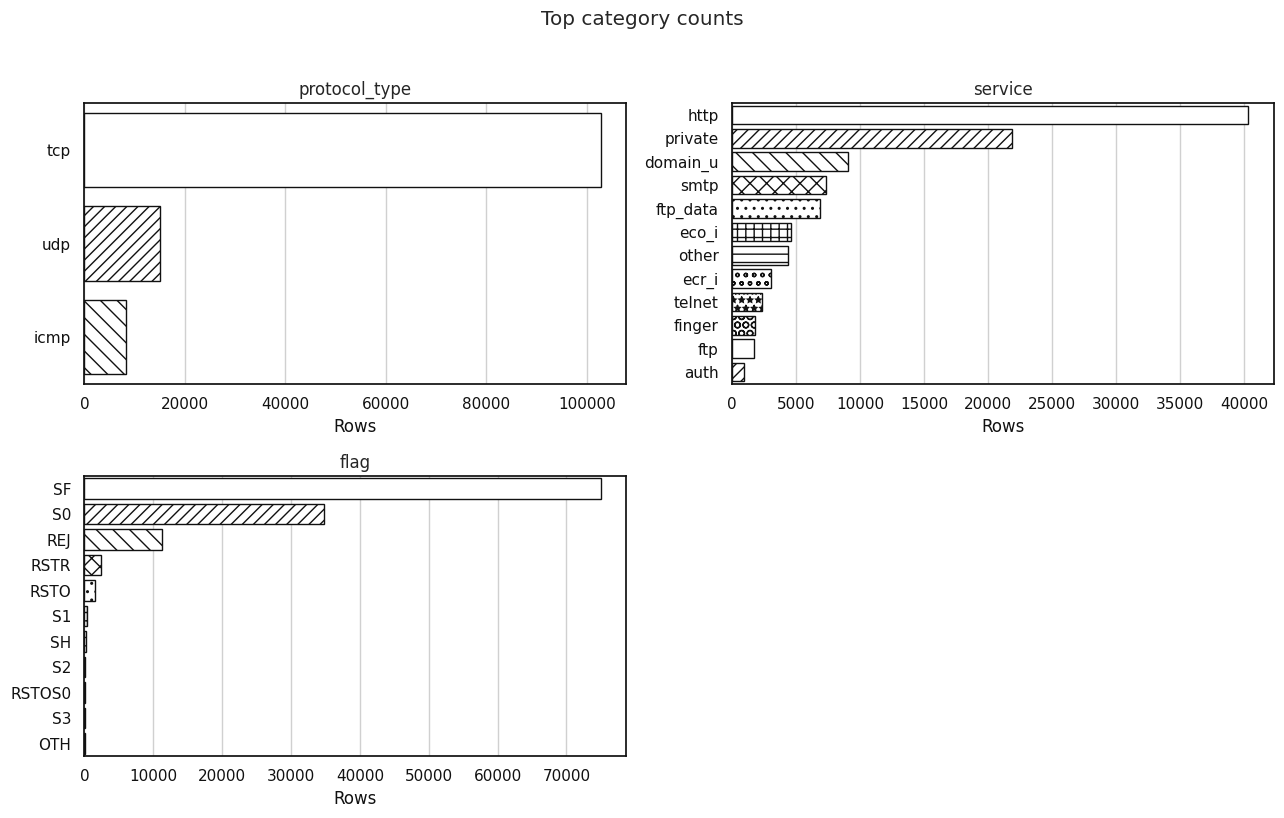

In [7]:
plot_numeric_distributions(df, [c for c in PREFERRED_NUMERIC if c in numeric_cols][:9], "Selected numeric feature distributions")
plot_categorical_top_counts(df, [c for c in PREFERRED_CATEGORICAL if c in categorical_cols][:6], "Top category counts")

## Target Relationships

/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,absolute_correlation_with_target_code
same_srv_rate,0.7519
dst_host_srv_count,0.7225
dst_host_same_srv_rate,0.6938
logged_in,0.6902
dst_host_srv_serror_rate,0.6550
dst_host_serror_rate,0.6518
serror_rate,0.6507
srv_serror_rate,0.6483
count,0.5764
dst_host_count,0.3751


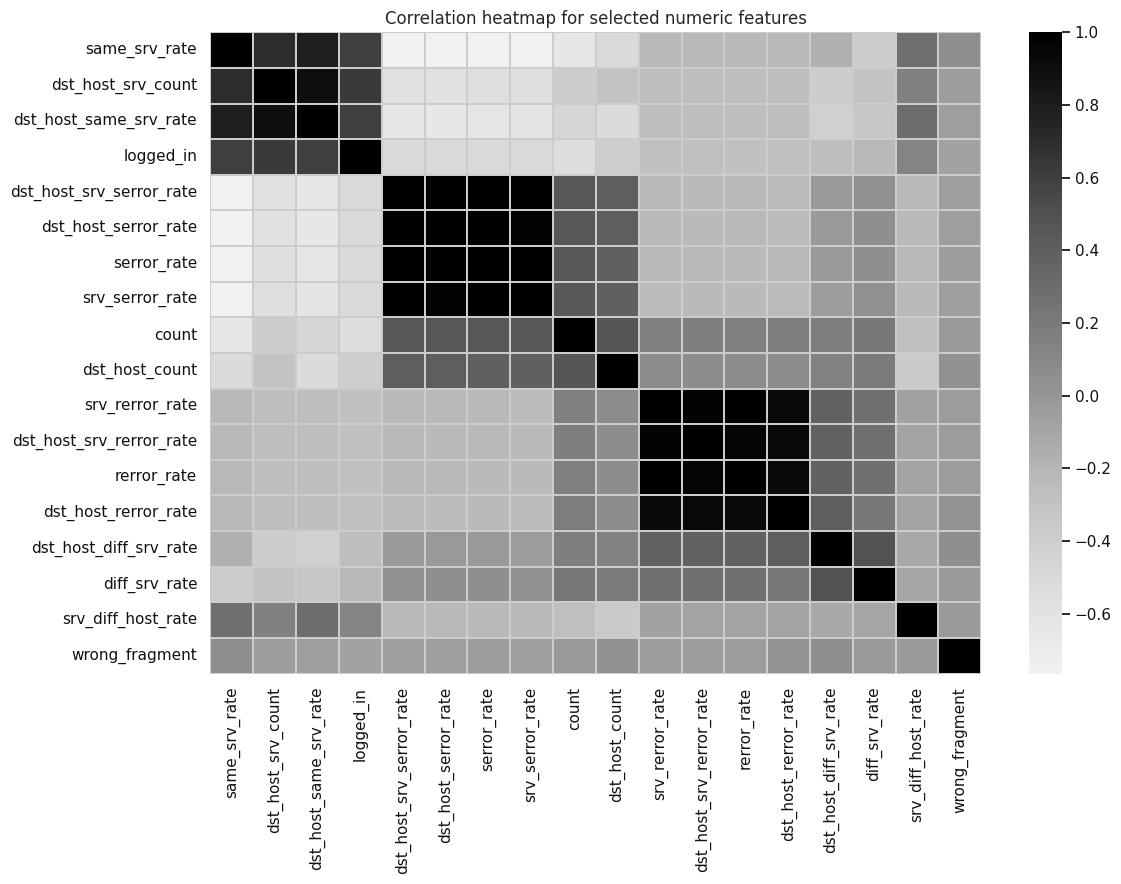

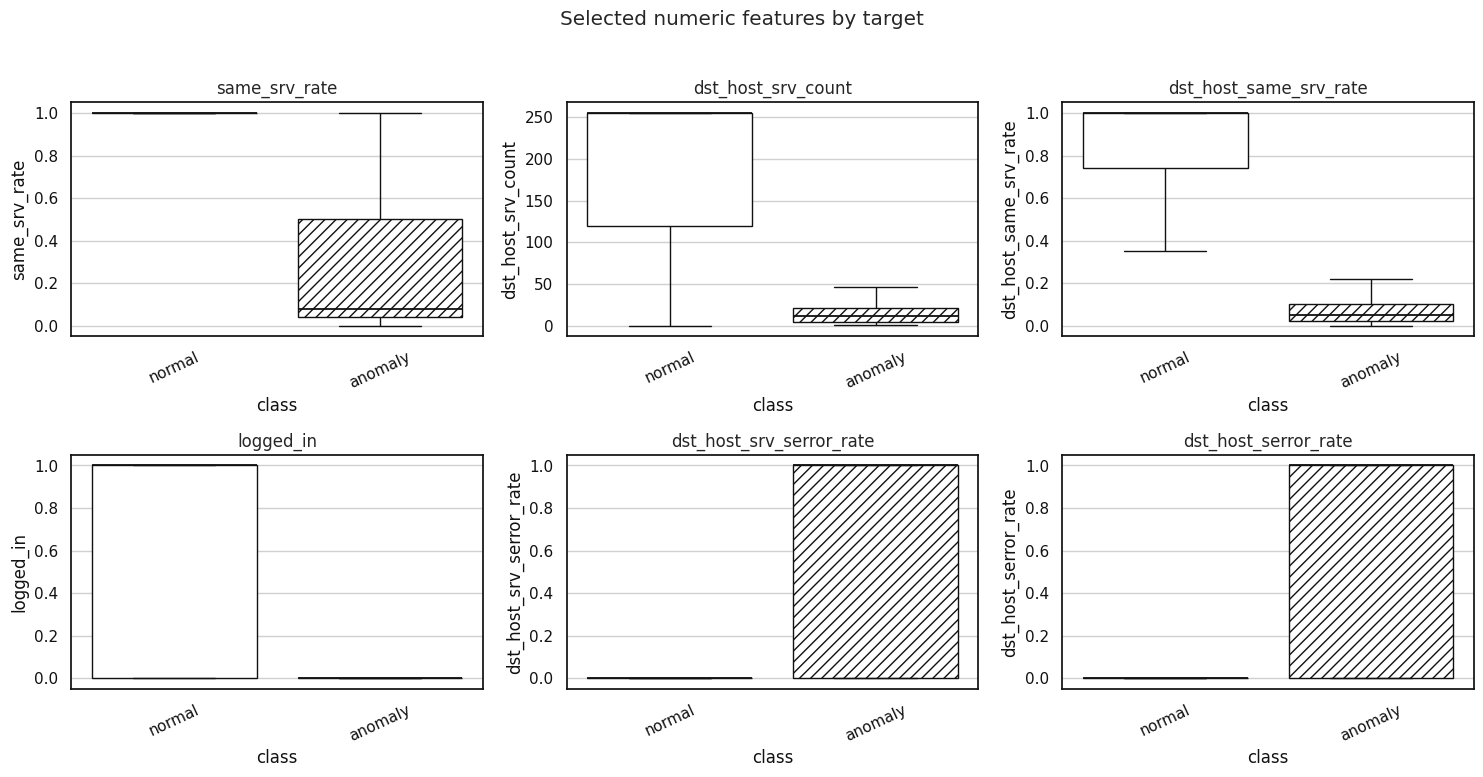

class,anomaly,normal
same_srv_rate,0.0800,1.0000
dst_host_srv_count,12.0000,255.0000
dst_host_same_srv_rate,0.0500,1.0000
logged_in,0.0000,1.0000
dst_host_srv_serror_rate,1.0000,0.0000
dst_host_serror_rate,1.0000,0.0000
serror_rate,1.0000,0.0000
srv_serror_rate,1.0000,0.0000
count,138.0000,4.0000
dst_host_count,255.0000,156.0000


In [8]:

# Target associations and correlation structure
assoc = target_association(df, TARGET_COL, numeric_cols, exclude=EXCLUDE_COLS)
display(assoc.head(20).rename("absolute_correlation_with_target_code").to_frame())

selected_numeric = assoc.head(18).index.tolist()
if len(selected_numeric) < 2:
    selected_numeric = numeric_cols[:18]

plot_correlation_heatmap(df, selected_numeric, "Correlation heatmap for selected numeric features")
plot_numeric_by_target(df, TARGET_COL, selected_numeric[:6], "Selected numeric features by target")

if selected_numeric:
    grouped_median = df.groupby(TARGET_COL)[selected_numeric[:10]].median(numeric_only=True).T
    display(grouped_median)


## Advanced EDA

This section extends the baseline EDA with model-preparation checks: target imbalance, duplicate structure, zero-heavy features, outliers, skewness, correlated pairs, low-variance signals, PCA separation, and mutual-information feature ranking.

In [9]:

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

ADVANCED_SAMPLE_SIZE = 10_000
CORRELATION_THRESHOLD = 0.85
ZERO_HEAVY_THRESHOLD = 0.90
DOMINANT_VALUE_THRESHOLD = 0.95
LOW_VARIANCE_THRESHOLD = 1e-8

def clean_numeric_frame(data, columns):
    if not columns:
        return pd.DataFrame(index=data.index)
    return data[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

def target_counts_table(data, target_col):
    counts = data[target_col].astype("string").fillna("<NA>").value_counts(dropna=False)
    table = counts.rename_axis(target_col).reset_index(name="count")
    table["percent"] = (table["count"] / len(data) * 100).round(3)
    table["imbalance_ratio_vs_minority"] = (table["count"] / table["count"].min()).round(3)
    return table

def plot_horizontal_counts(table, label_col, value_col="count", title="Count plot", color="white"):
    if table.empty:
        display(Markdown("No rows available for plotting."))
        return
    plt.figure(figsize=(9, max(3, 0.35 * len(table))))
    ax = sns.barplot(data=table, x=value_col, y=label_col, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title(title)
    plt.xlabel(value_col.replace("_", " ").title())
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def describe_binary_imbalance(data, target_col):
    table = target_counts_table(data, target_col)
    display(table)
    plot_horizontal_counts(table, target_col, title="Class counts", color="white")
    if len(table) == 2:
        majority = table.iloc[0]
        minority = table.iloc[-1]
        display(Markdown(
            f"Binary target detected. Majority class `{majority[target_col]}` has "
            f"{majority['count']:,} rows; minority class `{minority[target_col]}` has "
            f"{minority['count']:,} rows. Majority/minority ratio: "
            f"{majority['imbalance_ratio_vs_minority']:.3f}:1."
        ))
    else:
        display(Markdown(f"Target has {len(table)} labels, so this is not a binary-only target."))
    return table

def attack_type_analysis(data, target_col):
    target_values = data[target_col].astype("string").fillna("<NA>")
    target_table = target_counts_table(data, target_col)
    if len(target_table) > 2:
        attack_table = target_table.copy()
        display(Markdown("The target column itself contains multiple labels; treating non-normal labels as attack types."))
    else:
        candidate_cols = [
            c for c in data.columns
            if c != target_col and c.lower() in {"attack", "attack_type", "attack_cat", "attack_category", "label_detail"}
        ]
        if not candidate_cols:
            display(Markdown("No separate multi-class attack label column found. This KDDTrain+ file exposes `class` as binary `normal` / `anomaly`, so attack-family analysis is not available from this file alone."))
            return pd.DataFrame()
        attack_col = candidate_cols[0]
        display(Markdown(f"Using `{attack_col}` for attack-type analysis."))
        attack_table = target_counts_table(data, attack_col)
    display(attack_table.head(30))
    plot_horizontal_counts(attack_table.head(20), attack_table.columns[0], title="Attack type counts", color="white")
    return attack_table


## Binary Class Imbalance Analysis

,class,count,percent,imbalance_ratio_vs_minority
0,normal,67343,53.4580,1.1490
1,anomaly,58630,46.5420,1.0000


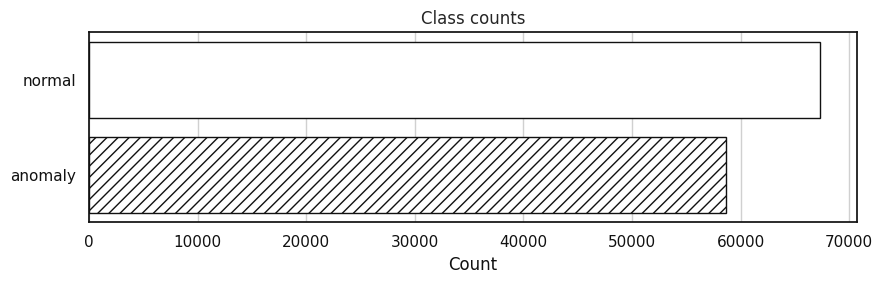

Binary target detected. Majority class `normal` has 67,343 rows; minority class `anomaly` has 58,630 rows. Majority/minority ratio: 1.149:1.

In [10]:

class_balance = describe_binary_imbalance(df, TARGET_COL)


## Attack Type Analysis

In [11]:

attack_type_summary = attack_type_analysis(df, TARGET_COL)


No separate multi-class attack label column found. This KDDTrain+ file exposes `class` as binary `normal` / `anomaly`, so attack-family analysis is not available from this file alone.

## Duplicate Analysis

,metric,value
0,duplicate_rows_keep_first,9
1,rows_in_duplicate_groups,17
2,duplicate_groups,8


,class,rows_in_duplicate_groups,percent_of_duplicate_rows
0,anomaly,17,100.0000


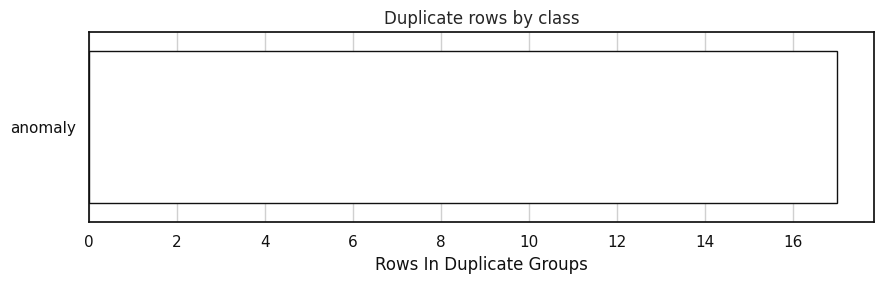

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,duplicate_group_size
4,0,icmp,ecr_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1,1,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,3
0,0,icmp,eco_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1,1,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
2,0,icmp,eco_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,7,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,2,2,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
1,0,icmp,eco_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,2,2,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
3,0,icmp,eco_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,45,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1,1,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
5,0,icmp,ecr_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,3,3,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
6,0,icmp,ecr_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,5,5,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2
7,0,icmp,ecr_i,SF,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,2,2,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,anomaly,2


In [12]:

duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicate_mask].copy()

duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_rows_keep_first", "rows_in_duplicate_groups", "duplicate_groups"],
    "value": [
        int(df.duplicated().sum()),
        int(duplicate_mask.sum()),
        int(df[duplicate_mask].value_counts(dropna=False).shape[0]) if duplicate_mask.any() else 0,
    ],
})
display(duplicate_summary)

if duplicate_mask.any():
    duplicate_by_target = (
        duplicate_rows[TARGET_COL]
        .astype("string")
        .fillna("<NA>")
        .value_counts()
        .rename_axis(TARGET_COL)
        .reset_index(name="rows_in_duplicate_groups")
    )
    duplicate_by_target["percent_of_duplicate_rows"] = (duplicate_by_target["rows_in_duplicate_groups"] / len(duplicate_rows) * 100).round(3)
    display(duplicate_by_target)
    plot_horizontal_counts(duplicate_by_target, TARGET_COL, "rows_in_duplicate_groups", "Duplicate rows by class", color="white")

    duplicate_group_sizes = (
        df[duplicate_mask]
        .groupby(df.columns.tolist(), dropna=False)
        .size()
        .reset_index(name="duplicate_group_size")
        .sort_values("duplicate_group_size", ascending=False)
    )
    display(duplicate_group_sizes.head(10))
else:
    display(Markdown("No duplicate rows found."))


## Missing And Zero-Heavy Column Analysis

,dtype,missing_count,missing_percent,unique_values,zero_count,zero_percent,is_zero_heavy
num_outbound_cmds,int64,0,0.0000,1,125973,100.0000,True
is_host_login,int64,0,0.0000,2,125972,99.9990,True
urgent,int64,0,0.0000,4,125964,99.9930,True
land,int64,0,0.0000,2,125948,99.9800,True
num_shells,int64,0,0.0000,3,125926,99.9630,True
su_attempted,int64,0,0.0000,3,125893,99.9360,True
num_failed_logins,int64,0,0.0000,6,125851,99.9030,True
root_shell,int64,0,0.0000,2,125804,99.8660,True
num_file_creations,int64,0,0.0000,35,125686,99.7720,True
num_access_files,int64,0,0.0000,10,125602,99.7050,True


,dtype,zero_count,zero_percent,unique_values
num_outbound_cmds,int64,125973,100.0000,1
is_host_login,int64,125972,99.9990,2
urgent,int64,125964,99.9930,4
land,int64,125948,99.9800,2
num_shells,int64,125926,99.9630,3
su_attempted,int64,125893,99.9360,3
num_failed_logins,int64,125851,99.9030,6
root_shell,int64,125804,99.8660,2
num_file_creations,int64,125686,99.7720,35
num_access_files,int64,125602,99.7050,10


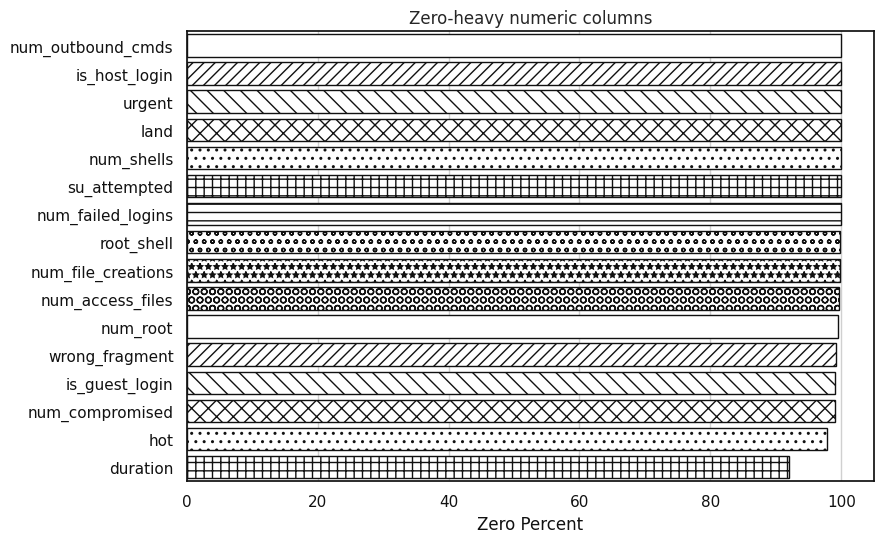

In [13]:

missing_counts = df.isna().sum()
missing_zero_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": missing_counts,
    "missing_percent": (missing_counts / len(df) * 100).round(3),
    "unique_values": df.nunique(dropna=False),
})

numeric_for_zero = clean_numeric_frame(df, numeric_cols)
zero_counts = numeric_for_zero.eq(0).sum()
zero_percent = (zero_counts / len(df) * 100).round(3)
missing_zero_table["zero_count"] = 0
missing_zero_table["zero_percent"] = 0.0
missing_zero_table.loc[zero_counts.index, "zero_count"] = zero_counts.astype(int)
missing_zero_table.loc[zero_percent.index, "zero_percent"] = zero_percent
missing_zero_table["is_zero_heavy"] = missing_zero_table["zero_percent"] >= ZERO_HEAVY_THRESHOLD * 100

missing_zero_table = missing_zero_table.sort_values(["missing_percent", "zero_percent"], ascending=False)
display(missing_zero_table.head(25))

zero_heavy_columns = missing_zero_table[missing_zero_table["is_zero_heavy"]].sort_values("zero_percent", ascending=False)
display(zero_heavy_columns[["dtype", "zero_count", "zero_percent", "unique_values"]])

if not zero_heavy_columns.empty:
    plot_table = zero_heavy_columns.reset_index(names="column").head(20)
    plot_horizontal_counts(plot_table, "column", "zero_percent", "Zero-heavy numeric columns", color="white")
else:
    display(Markdown(f"No numeric columns have at least {ZERO_HEAVY_THRESHOLD:.0%} zero values."))


## IQR-Based Outlier Count Table

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,non_null
32,dst_host_same_src_port_rate,0.0000,0.0600,0.0600,-0.0900,0.1500,25052,19.8870,125973
2,dst_bytes,0.0000,516.0000,516.0000,-774.0000,"1,290.0000",23579,18.7180,125973
1,src_bytes,0.0000,276.0000,276.0000,-414.0000,690.0000,13840,10.9860,125973
20,srv_count,2.0000,18.0000,16.0000,-22.0000,42.0000,12054,9.5690,125973
33,dst_host_srv_diff_host_rate,0.0000,0.0200,0.0200,-0.0300,0.0500,11682,9.2730,125973
31,dst_host_diff_srv_rate,0.0000,0.0700,0.0700,-0.1050,0.1750,10550,8.3750,125973
26,diff_srv_rate,0.0000,0.0600,0.0600,-0.0900,0.1500,7788,6.1820,125973
19,count,2.0000,143.0000,141.0000,-209.5000,354.5000,3157,2.5060,125973
3,land,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,125973
0,duration,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,125973


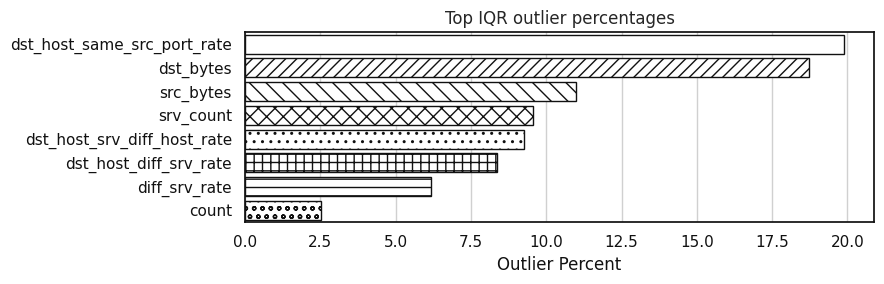

In [14]:

outlier_rows = []
for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        continue
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    if np.isclose(iqr, 0):
        outlier_count = 0
    else:
        outlier_count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_count / len(values) * 100, 3),
        "non_null": int(values.shape[0]),
    })

iqr_outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(iqr_outlier_table.head(25))

plot_iqr = iqr_outlier_table[iqr_outlier_table["outlier_count"] > 0].head(15)
if not plot_iqr.empty:
    plot_horizontal_counts(plot_iqr, "column", "outlier_percent", "Top IQR outlier percentages", color="white")
else:
    display(Markdown("No IQR outliers detected after excluding zero-IQR columns."))


## Skewness Ranking For Numeric Columns

,skewness,abs_skewness
is_host_login,354.9268,354.9268
dst_bytes,290.0529,290.0529
num_compromised,250.1079,250.1079
num_root,236.9137,236.9137
src_bytes,190.6693,190.6693
urgent,149.9145,149.9145
land,70.9651,70.9651
num_shells,59.5922,59.5922
num_file_creations,55.6653,55.6653
num_failed_logins,53.7644,53.7644


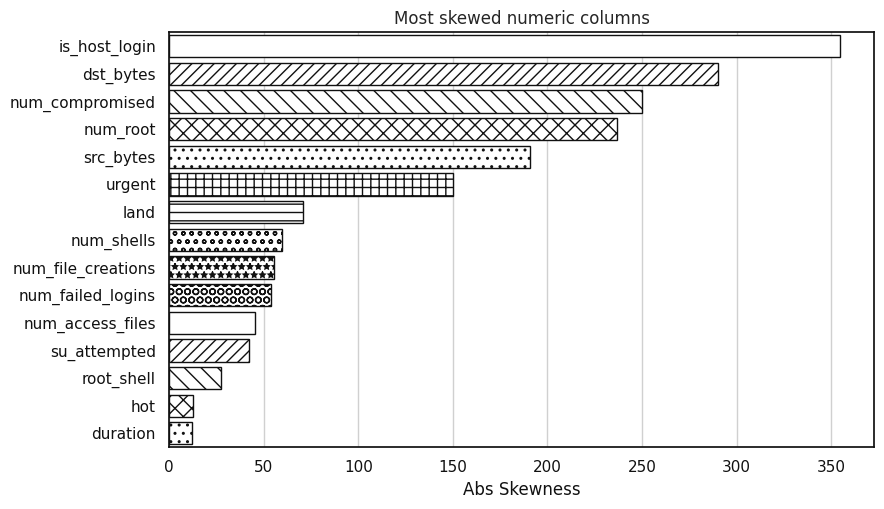

In [15]:

skew_values = clean_numeric_frame(df, numeric_cols).skew(numeric_only=True).dropna()
skewness_table = (
    skew_values.rename("skewness")
    .to_frame()
    .assign(abs_skewness=lambda x: x["skewness"].abs())
    .sort_values("abs_skewness", ascending=False)
)
display(skewness_table.head(25))

plot_skew = skewness_table.head(15).reset_index(names="column")
if not plot_skew.empty:
    plot_horizontal_counts(plot_skew, "column", "abs_skewness", "Most skewed numeric columns", color="white")


## Highly Correlated Feature Pairs

In [16]:

numeric_clean = clean_numeric_frame(df, numeric_cols)
corr_matrix = numeric_clean.corr().abs()
upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
correlated_pairs = (
    corr_matrix.where(upper_mask)
    .stack()
    .rename("absolute_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .sort_values("absolute_correlation", ascending=False)
)
highly_correlated_pairs = correlated_pairs[correlated_pairs["absolute_correlation"] >= CORRELATION_THRESHOLD]
display(highly_correlated_pairs.head(30))

display(Markdown(f"Found {len(highly_correlated_pairs):,} feature pairs with absolute correlation >= {CORRELATION_THRESHOLD:.2f}."))


,feature_1,feature_2,absolute_correlation
354,num_compromised,num_root,0.9988
820,serror_rate,srv_serror_rate,0.9933
898,rerror_rate,srv_rerror_rate,0.9890
871,srv_serror_rate,dst_host_srv_serror_rate,0.9863
1327,dst_host_serror_rate,dst_host_srv_serror_rate,0.9851
833,serror_rate,dst_host_srv_serror_rate,0.9811
832,serror_rate,dst_host_serror_rate,0.9794
870,srv_serror_rate,dst_host_serror_rate,0.9776
949,srv_rerror_rate,dst_host_srv_rerror_rate,0.9702
911,rerror_rate,dst_host_srv_rerror_rate,0.9644


Found 15 feature pairs with absolute correlation >= 0.85.

## Low-Variance Feature Detection

In [17]:

low_variance_rows = []
for col in [c for c in df.columns if c != TARGET_COL]:
    series = df[col]
    value_counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
    dominant_percent = float(value_counts.iloc[0] / len(series) * 100) if len(value_counts) else np.nan
    row = {
        "column": col,
        "dtype": str(series.dtype),
        "unique_values": int(series.nunique(dropna=False)),
        "dominant_value": value_counts.index[0] if len(value_counts) else None,
        "dominant_percent": round(dominant_percent, 3),
        "near_constant_by_dominance": dominant_percent >= DOMINANT_VALUE_THRESHOLD * 100 if len(value_counts) else False,
    }
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        row["variance"] = float(values.var(skipna=True)) if values.notna().any() else np.nan
        row["zero_or_near_zero_variance"] = bool(pd.notna(row["variance"]) and row["variance"] <= LOW_VARIANCE_THRESHOLD)
    else:
        row["variance"] = np.nan
        row["zero_or_near_zero_variance"] = False
    low_variance_rows.append(row)

low_variance_table = pd.DataFrame(low_variance_rows).sort_values(
    ["zero_or_near_zero_variance", "near_constant_by_dominance", "dominant_percent"],
    ascending=[False, False, False],
)
display(low_variance_table.head(30))

low_variance_candidates = low_variance_table[
    low_variance_table["zero_or_near_zero_variance"] | low_variance_table["near_constant_by_dominance"]
]
display(low_variance_candidates)


,column,dtype,unique_values,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
19,num_outbound_cmds,int64,1,0,100.0000,True,0.0000,True
20,is_host_login,int64,2,0,99.9990,True,0.0000,False
8,urgent,int64,4,0,99.9930,True,0.0002,False
6,land,int64,2,0,99.9800,True,0.0002,False
17,num_shells,int64,3,0,99.9630,True,0.0005,False
14,su_attempted,int64,3,0,99.9360,True,0.0020,False
10,num_failed_logins,int64,6,0,99.9030,True,0.0020,False
13,root_shell,int64,2,0,99.8660,True,0.0013,False
16,num_file_creations,int64,35,0,99.7720,True,0.2342,False
18,num_access_files,int64,10,0,99.7050,True,0.0099,False


,column,dtype,unique_values,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
19,num_outbound_cmds,int64,1,0,100.0000,True,0.0000,True
20,is_host_login,int64,2,0,99.9990,True,0.0000,False
8,urgent,int64,4,0,99.9930,True,0.0002,False
6,land,int64,2,0,99.9800,True,0.0002,False
17,num_shells,int64,3,0,99.9630,True,0.0005,False
14,su_attempted,int64,3,0,99.9360,True,0.0020,False
10,num_failed_logins,int64,6,0,99.9030,True,0.0020,False
13,root_shell,int64,2,0,99.8660,True,0.0013,False
16,num_file_creations,int64,35,0,99.7720,True,0.2342,False
18,num_access_files,int64,10,0,99.7050,True,0.0099,False


## PCA Visualization On Sampled Numeric Features

,component,explained_variance_percent
0,PC1,19.9610
1,PC2,13.7950


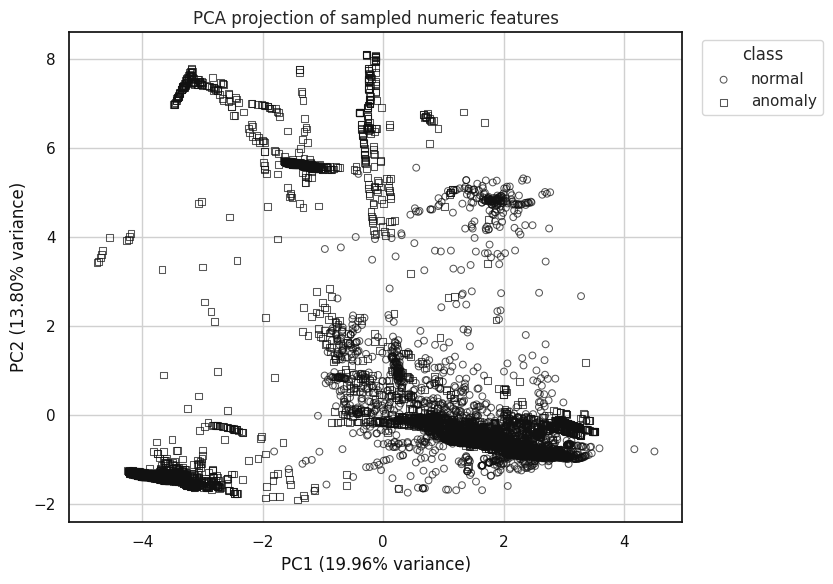

In [18]:

pca_numeric_cols = [
    col for col in numeric_cols
    if df[col].nunique(dropna=True) > 1 and not pd.to_numeric(df[col], errors="coerce").dropna().empty
]

if len(pca_numeric_cols) < 2:
    display(Markdown("PCA requires at least two non-constant numeric features."))
    pca_result = pd.DataFrame()
else:
    pca_sample = sampled(df[[TARGET_COL] + pca_numeric_cols], ADVANCED_SAMPLE_SIZE)
    X_numeric = clean_numeric_frame(pca_sample, pca_numeric_cols)
    X_imputed = SimpleImputer(strategy="median").fit_transform(X_numeric)
    X_scaled = StandardScaler().fit_transform(X_imputed)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X_scaled)
    pca_result = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        TARGET_COL: pca_sample[TARGET_COL].astype("string").fillna("<NA>").to_numpy(),
    })
    explained = pca.explained_variance_ratio_ * 100
    display(pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_percent": explained.round(3),
    }))

    scatter_with_markers(
        pca_result,
        "PC1",
        "PC2",
        TARGET_COL,
        "PCA projection of sampled numeric features",
        xlabel=f"PC1 ({explained[0]:.2f}% variance)",
        ylabel=f"PC2 ({explained[1]:.2f}% variance)",
    )


## Feature Ranking Against Target Using Mutual Information

,feature,mutual_information,feature_type
0,src_bytes,0.5657,numeric
1,service,0.4655,categorical
2,dst_bytes,0.4403,numeric
3,same_srv_rate,0.3678,numeric
4,diff_srv_rate,0.3605,numeric
5,flag,0.3600,categorical
6,dst_host_srv_count,0.3373,numeric
7,dst_host_same_srv_rate,0.3115,numeric
8,logged_in,0.2928,numeric
9,dst_host_serror_rate,0.2874,numeric


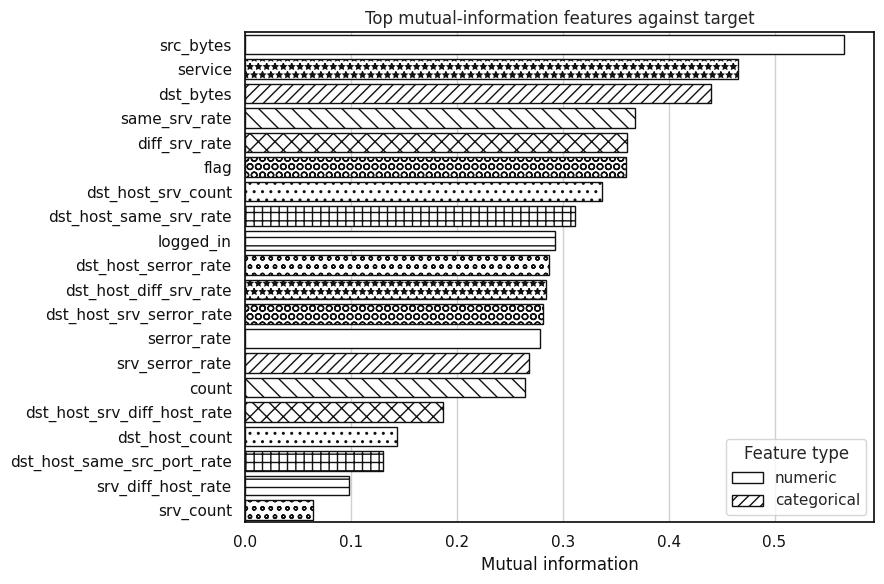

In [19]:

feature_cols = [c for c in df.columns if c != TARGET_COL]
y = pd.Series(pd.factorize(df[TARGET_COL].astype("string").fillna("<NA>"))[0], index=df.index)

X_parts = []
discrete_features = []
encoded_feature_names = []

for col in feature_cols:
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        fill_value = values.median() if values.notna().any() else 0
        X_parts.append(values.fillna(fill_value).to_numpy())
        discrete_features.append(False)
    else:
        encoded = pd.factorize(series.astype("string").fillna("<NA>"))[0]
        X_parts.append(encoded)
        discrete_features.append(True)
    encoded_feature_names.append(col)

if not X_parts:
    mi_feature_ranking = pd.DataFrame()
    display(Markdown("No features available for mutual information ranking."))
else:
    X_mi = np.column_stack(X_parts)
    mi_scores = mutual_info_classif(
        X_mi,
        y,
        discrete_features=np.array(discrete_features, dtype=bool),
        random_state=RANDOM_STATE,
    )
    mi_feature_ranking = (
        pd.DataFrame({
            "feature": encoded_feature_names,
            "mutual_information": mi_scores,
            "feature_type": ["categorical" if flag else "numeric" for flag in discrete_features],
        })
        .sort_values("mutual_information", ascending=False)
        .reset_index(drop=True)
    )
    display(mi_feature_ranking.head(25))

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(data=mi_feature_ranking.head(20), x="mutual_information", y="feature", hue="feature_type", dodge=False, palette=print_palette(2), edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title("Top mutual-information features against target")
    plt.xlabel("Mutual information")
    plt.ylabel("")
    plt.legend(title="Feature type")
    plt.tight_layout()
    plt.show()
